# Prueba de preentrenamiento del modelo de 50M con Tiny Shakespeare

Entrena el modelo sobre Tiny Shakespeare guardado localmente, evalúa periódicamente sobre un conjunto de validación, genera texto, representa las curvas de pérdida y guarda un checkpoint. Funciona con CUDA, Apple MPS o CPU.

## Preparación

El archivo de datos debe estar en `data/tinyshakespeare/input.txt` dentro del proyecto.

Ejecuta este notebook con el directorio del proyecto como directorio de trabajo. La siguiente celda instala el paquete local y las dependencias necesarias.


In [1]:
%pip install -q -e ".[training]" jupyterlab ipywidgets

ERROR: file:///workspace/notebooks/notebooks does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tiktoken

PROJECT_ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents)
                     if (path / 'src' / 'llm_mini_lab').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del proyecto llm-mini-lab')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from llm_mini_lab.model import GPTModel
from llm_mini_lab.pretraining import (
    GPT_CONFIG_50M, generate_text_simple,
    text_to_token_ids, token_ids_to_text,
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('PyTorch:', torch.__version__)
print('Dispositivo:', device)
if device.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GiB):', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))

PyTorch: 2.11.0+cu128
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM (GiB): 11.6


In [3]:
SEED = 123
MAX_LENGTH = 128
BATCH_SIZE = 8
MAX_TOKENS = 1_000_000
MAX_UPDATES = MAX_TOKENS // (BATCH_SIZE * MAX_LENGTH)
EVAL_EVERY = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1

assert MAX_UPDATES > 0
assert EVAL_EVERY > 0

torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

In [7]:
class GPTTextDataset(Dataset):
    def __init__(self, token_ids, max_length, stride):
        self.token_ids = token_ids
        self.max_length = max_length
        self.stride = stride

    def __len__(self):
        return max(
            0,
            (len(self.token_ids) - self.max_length - 1) // self.stride + 1,
        )

    def __getitem__(self, index):
        start = index * self.stride
        end = start + self.max_length
        inputs = self.token_ids[start:end]
        targets = self.token_ids[start + 1:end + 1]
        return (
            torch.tensor(inputs, dtype=torch.long),
            torch.tensor(targets, dtype=torch.long),
        )


text_path = PROJECT_ROOT / 'data' / 'tinyshakespeare' / 'input.txt'
if not text_path.is_file():
    raise FileNotFoundError(
        f'No se encontró Tiny Shakespeare en {text_path}. '
        'Guarda el archivo como data/tinyshakespeare/input.txt.'
    )

text = text_path.read_text(encoding='utf-8')
tokenizer = tiktoken.get_encoding('gpt2')
token_ids = tokenizer.encode(text)

# División secuencial para impedir que las ventanas de train y validación se solapen.
split_index = int(0.9 * len(token_ids))
train_token_ids = token_ids[:split_index]
val_token_ids = token_ids[split_index:]

train_dataset = GPTTextDataset(
    train_token_ids, max_length=MAX_LENGTH, stride=MAX_LENGTH
)
val_dataset = GPTTextDataset(
    val_token_ids, max_length=MAX_LENGTH, stride=MAX_LENGTH
)

assert len(train_dataset) > 0, 'El conjunto de entrenamiento no contiene secuencias'
assert len(val_dataset) > 0, 'El conjunto de validación no contiene secuencias'

train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=train_generator,
)
val_eval_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

xb, yb = next(iter(train_loader))
assert xb.shape == yb.shape == (BATCH_SIZE, MAX_LENGTH)
assert torch.equal(yb[:, :-1], xb[:, 1:])

print(f'Archivo: {text_path}')
print(f'Caracteres: {len(text):,}')
print(f'Tokens totales: {len(token_ids):,}')
print(f'Secuencias de entrenamiento: {len(train_dataset):,}')
print(f'Secuencias de validación: {len(val_dataset):,}')
print('Micro-batch:', tuple(xb.shape))
print(f'Actualizaciones planificadas: {MAX_UPDATES:,}')

Archivo: /workspace/notebooks/data/tinyshakespeare/input.txt
Caracteres: 1,048,576
Tokens totales: 316,440
Secuencias de entrenamiento: 2,224
Secuencias de validación: 247
Micro-batch: (8, 128)
Actualizaciones planificadas: 976


In [8]:
cfg = {**GPT_CONFIG_50M, 'context_length': MAX_LENGTH}
model = GPTModel(cfg)
model.out_head.weight = model.tok_emb.weight
model = model.to(device)

n_params = sum(parameter.numel() for parameter in model.parameters())
assert n_params <= 50_000_000, f'El modelo tiene {n_params:,} parámetros'
print(f'Parámetros entrenables: {n_params:,} ({n_params / 1e6:.2f}M)')

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

Parámetros entrenables: 47,854,080 (47.85M)


In [9]:
def evaluate_validation(model, data_loader, device):
    was_training = model.training
    model.eval()
    batch_losses = []

    with torch.inference_mode():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            loss = F.cross_entropy(
                logits.flatten(0, 1), targets.flatten()
            )
            batch_losses.append(loss.item())

    model.train(was_training)
    if not batch_losses:
        raise RuntimeError('El loader de validación no produjo ningún batch')
    return sum(batch_losses) / len(batch_losses)


model.train()
train_losses = []
val_loss_history = []
val_steps = []
tokens_seen = 0
train_iterator = iter(train_loader)

for update in range(1, MAX_UPDATES + 1):
    try:
        inputs, targets = next(train_iterator)
    except StopIteration:
        # Empieza otra época y vuelve a mezclar las secuencias.
        train_iterator = iter(train_loader)
        inputs, targets = next(train_iterator)

    inputs = inputs.to(device)
    targets = targets.to(device)
    optimizer.zero_grad(set_to_none=True)
    logits = model(inputs)
    loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())

    if not torch.isfinite(loss):
        raise FloatingPointError(
            f'Pérdida no finita en la actualización {update}'
        )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    train_losses.append(loss.item())
    tokens_seen += inputs.numel()

    should_evaluate = update % EVAL_EVERY == 0 or update == MAX_UPDATES
    if should_evaluate:
        mean_val_loss = evaluate_validation(model, val_eval_loader, device)
        val_loss_history.append(mean_val_loss)
        val_steps.append(update)
        print(
            f'Actualización {update:04d}/{MAX_UPDATES} | '
            f'train loss {loss.item():.4f} | val loss {mean_val_loss:.4f}'
        )
    elif update == 1 or update % 10 == 0:
        print(
            f'Actualización {update:04d}/{MAX_UPDATES} | '
            f'train loss {loss.item():.4f}'
        )

assert len(train_losses) == MAX_UPDATES
print(f'Entrenamiento completado: {tokens_seen:,} tokens')

Actualización 0001/976 | train loss 329.0804
Actualización 0010/976 | train loss 55.7844
Actualización 0020/976 | train loss 44.2174
Actualización 0030/976 | train loss 40.8083
Actualización 0040/976 | train loss 36.6449
Actualización 0050/976 | train loss 31.6968
Actualización 0060/976 | train loss 32.6143
Actualización 0070/976 | train loss 28.6166
Actualización 0080/976 | train loss 26.3647
Actualización 0090/976 | train loss 24.9428
Actualización 0100/976 | train loss 26.1242 | val loss 24.3832
Actualización 0110/976 | train loss 22.2802
Actualización 0120/976 | train loss 20.7716
Actualización 0130/976 | train loss 20.2711
Actualización 0140/976 | train loss 19.9686
Actualización 0150/976 | train loss 19.1232
Actualización 0160/976 | train loss 17.9406
Actualización 0170/976 | train loss 17.3258
Actualización 0180/976 | train loss 16.0223
Actualización 0190/976 | train loss 15.2777
Actualización 0200/976 | train loss 14.5617 | val loss 15.1745
Actualización 0210/976 | train loss 1

In [10]:
# Evaluación final. Si la última actualización ya se evaluó, reutilizamos ese valor.
if val_steps and val_steps[-1] == MAX_UPDATES:
    mean_val_loss = val_loss_history[-1]
else:
    mean_val_loss = evaluate_validation(model, val_eval_loader, device)
    val_loss_history.append(mean_val_loss)
    val_steps.append(MAX_UPDATES)

print(f'Loss inicial de entrenamiento: {train_losses[0]:.4f}')
print(f'Loss final de entrenamiento: {train_losses[-1]:.4f}')
print(f'Loss final de validación: {mean_val_loss:.4f}')

Loss inicial de entrenamiento: 329.0804
Loss final de entrenamiento: 5.3993
Loss final de validación: 6.8898


In [11]:
prompt = text_to_token_ids('ROMEO:', tokenizer).to(device)
generated_ids = generate_text_simple(
    model, prompt, max_new_tokens=50, context_size=MAX_LENGTH
)
print('Muestra:', token_ids_to_text(generated_ids.cpu(), tokenizer))

checkpoint_path = PROJECT_ROOT / 'checkpoints' / 'gpt-50m-tinyshakespeare.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': cfg,
    'updates': len(train_losses),
    'tokens_seen': tokens_seen,
    'train_losses': train_losses,
    'val_losses': val_loss_history,
    'val_steps': val_steps,
}, checkpoint_path)
print('Checkpoint guardado en:', checkpoint_path)

Muestra: ROMEO:
I know not be not,
I am I have been,
And not the king,
The king,
The king,
And I have been not the king,
And,
And,
And not the king,

Checkpoint guardado en: /workspace/notebooks/checkpoints/gpt-50m-tinyshakespeare.pt


In [12]:
%pip install -q matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


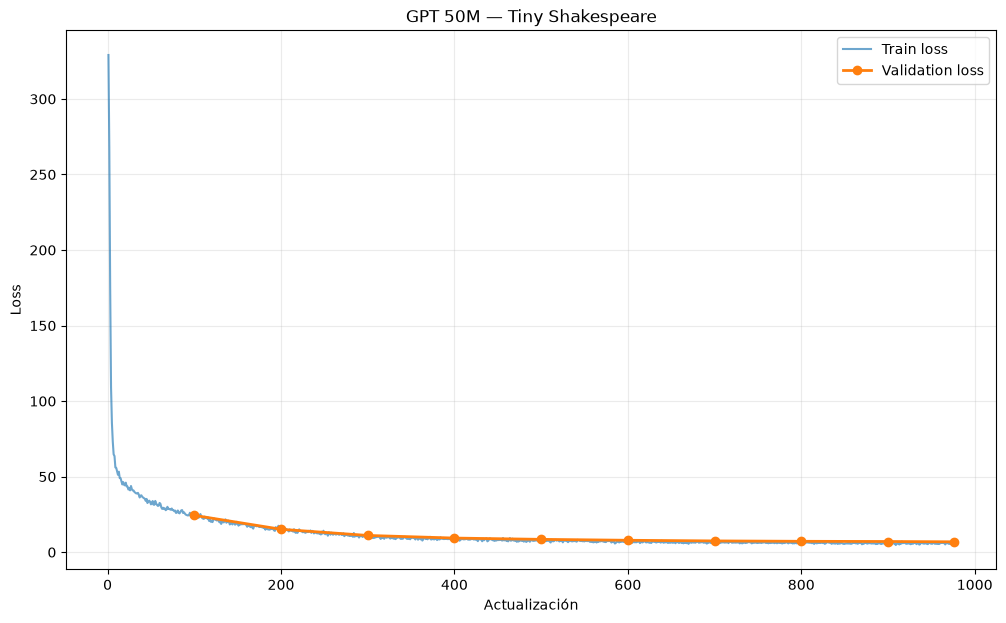

In [13]:
import matplotlib.pyplot as plt

train_steps = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 7))
plt.plot(train_steps, train_losses, alpha=0.65, label='Train loss')
plt.plot(
    val_steps,
    val_loss_history,
    marker='o',
    linewidth=2,
    label='Validation loss',
)


plt.title('GPT 50M — Tiny Shakespeare')
plt.xlabel('Actualización')
plt.ylabel('Loss')
plt.grid(alpha=0.25)
plt.legend()
plt.show()